# Gaussian Mixture Models & the EM Algorithm From Scratch

*Source:* `course-files/appendix/Homework/ecen758_hw/HW 2/hw2.ipynb` (ECEN 758, Homework 2).

A by-hand implementation of Expectation-Maximization: the mixture-density
**log-likelihood** of a two-component 1-D Gaussian mixture, one manual **E-step**
(posterior responsibilities) and **M-step** (parameter re-estimation), then a full EM
loop for the classic three-coin latent-variable problem, run from two different
initializations to show convergence.


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt


In [2]:
#https://towardsdatascience.com/implementing-expectation-maximisation-algorithm-from-scratch-with-python-9ccb2c8521b3/
#https://towardsdatascience.com/gaussian-mixture-models-gmms-from-theory-to-implementation-4406c7fe9847/
#used for both questions 3 and 4
D = np.array([1.0, 1.3, 2.2, 2.6, 2.8, 5.0, 7.3, 7.4, 7.5, 7.7])

mu1, mu2 = 6.63, 7.57
sigma1, sigma2 = 1.0, 1.0
pi1, pi2 = 0.5, 0.5

In [3]:
# Compute log-likelihood
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
log_likelihood = 0
for x in D:
    mixture_density = pi1 * norm.pdf(x, mu1, sigma1) + pi2 * norm.pdf(x, mu2, sigma2)
    log_likelihood += np.log(mixture_density)

print(f"Log-likelihood: {log_likelihood:.6f}")


Log-likelihood: -70.513264


In [4]:
#3b
# E-step:

n = len(D)
w = np.zeros((n, 2))

for j in range(n):
    likelihood_C1 = norm.pdf(D[j], mu1, sigma1) * pi1
    likelihood_C2 = norm.pdf(D[j], mu2, sigma2) * pi2
    
    total = likelihood_C1 + likelihood_C2
    w[j, 0] = likelihood_C1 / total
    w[j, 1] = likelihood_C2 / total

post_prob_df = pd.DataFrame({
    'Data Point': D,
    'wi1': w[:, 0],
    'wi2': w[:, 1]
})

print(post_prob_df)


   Data Point       wi1       wi2
0         1.0  0.996776  0.003224
1         1.3  0.995731  0.004269
2         2.2  0.990107  0.009893
3         2.6  0.985656  0.014344
4         2.8  0.982741  0.017259
5         5.0  0.878040  0.121960
6         7.3  0.453138  0.546862
7         7.4  0.429964  0.570036
8         7.5  0.407092  0.592908
9         7.7  0.362622  0.637378


In [5]:
#3c
# M-step, Update parameters

mu1_new = np.sum(w[:, 0] * D) / np.sum(w[:, 0])
mu2_new = np.sum(w[:, 1] * D) / np.sum(w[:, 1])

sigma1_new = np.sqrt(np.sum(w[:, 0] * (D - mu1_new)**2) / np.sum(w[:, 0]))
sigma2_new = np.sqrt(np.sum(w[:, 1] * (D - mu2_new)**2) / np.sum(w[:, 1]))

pi1_new = np.sum(w[:, 0]) / n
pi2_new = np.sum(w[:, 1]) / n

print("Updated Parameters:")
print(f"μ1 = {mu1_new:.6f}, μ2 = {mu2_new:.6f}")
print(f"σ1 = {sigma1_new:.6f}, σ2 = {sigma2_new:.6f}")
print(f"π1 = {pi1_new:.6f}, π2 = {pi2_new:.6f}")

Updated Parameters:
μ1 = 3.543108, μ2 = 7.263690
σ1 = 2.368092, σ2 = 0.886410
π1 = 0.748187, π2 = 0.251813


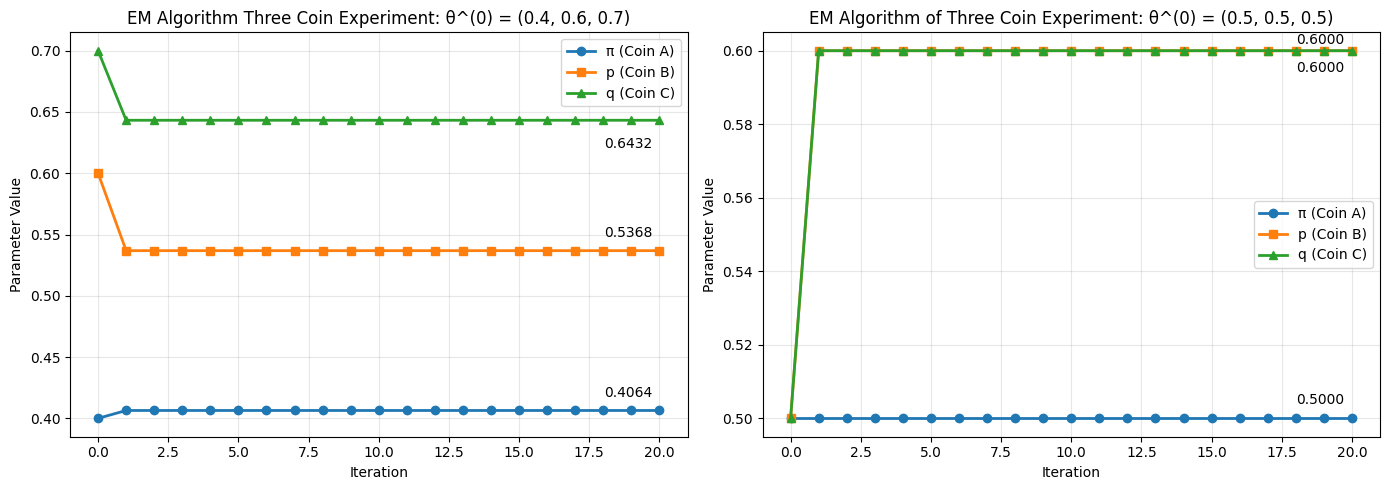

In [6]:
#Question 4g
#https://towardsdatascience.com/implementing-expectation-maximisation-algorithm-from-scratch-with-python-9ccb2c8521b3/
y = np.array([1, 1, 0, 1, 0, 0, 1, 0, 1, 1])

def e_step(y, pi, p, q):
    mu = np.zeros(len(y))
    for j in range(len(y)):
        num = pi * (p**y[j]) * ((1-p)**(1-y[j]))
        den = num + (1-pi) * (q**y[j]) * ((1-q)**(1-y[j]))
        mu[j] = num / den
    return mu

def m_step(y, mu):
    pi_new = np.mean(mu)
    p_new = np.sum(mu * y) / np.sum(mu)
    q_new = np.sum((1 - mu) * y) / np.sum(1 - mu)
    return pi_new, p_new, q_new

def run_em(y, pi, p, q, n_iter=20):
    pi_hist, p_hist, q_hist = [pi], [p], [q]
    for i in range(n_iter):
        mu = e_step(y, pi, p, q)
        pi, p, q = m_step(y, mu)
        pi_hist.append(pi)
        p_hist.append(p)
        q_hist.append(q)
    return np.array(pi_hist), np.array(p_hist), np.array(q_hist)

pi1, p1, q1 = run_em(y, 0.4, 0.6, 0.7)
pi2, p2, q2 = run_em(y, 0.5, 0.5, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#https://www.datacenterknowledge.com/data-center-software/how-to-type-the-theta-symbol
# θ^(0) = (0.4, 0.6, 0.7)
axes[0].plot(range(21), pi1, 'o-', label='π (Coin A)', linewidth=2)
axes[0].plot(range(21), p1, 's-', label='p (Coin B)', linewidth=2)
axes[0].plot(range(21), q1, '^-', label='q (Coin C)', linewidth=2)
axes[0].annotate(f'{pi1[-1]:.4f}', xy=(20, pi1[-1]), xytext=(-40,10), 
                textcoords='offset points')
axes[0].annotate(f'{p1[-1]:.4f}', xy=(20, p1[-1]), xytext=(-40,10), 
                textcoords='offset points')
axes[0].annotate(f'{q1[-1]:.4f}', xy=(20, q1[-1]), xytext=(-40,-20), 
                textcoords='offset points')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Parameter Value')
axes[0].set_title(f'EM Algorithm Three Coin Experiment: θ^(0) = (0.4, 0.6, 0.7)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# θ(0) = (0.5, 0.5, 0.5)
axes[1].plot(range(21), pi2, 'o-', label='π (Coin A)', linewidth=2)
axes[1].plot(range(21), p2, 's-', label='p (Coin B)', linewidth=2)
axes[1].plot(range(21), q2, '^-', label='q (Coin C)', linewidth=2)
axes[1].annotate(f'{pi2[-1]:.4f}', xy=(20, pi2[-1]), xytext=(-40,10), 
                textcoords='offset points')
axes[1].annotate(f'{p2[-1]:.4f}', xy=(20, p2[-1]), xytext=(-40,5), 
                textcoords='offset points')
axes[1].annotate(f'{q2[-1]:.4f}', xy=(20, q2[-1]), xytext=(-40,-15), 
                textcoords='offset points')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Parameter Value')
axes[1].set_title(f'EM Algorithm of Three Coin Experiment: θ^(0) = (0.5, 0.5, 0.5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()